# **CNN con PyTorch**

---



## **1. ¿Qué es Flatten?**

La operación **Flatten** transforma una entrada multidimensional (como una imagen con múltiples canales y tamaño) en un **vector unidimensional**. Es clave antes de pasar la salida de una CNN a capas densas que esperan vectores como entrada.

Por ejemplo, una imagen de salida de la última capa convolucional con forma `(3, 3, 2)` (3x3 píxeles con 2 canales) se convierte en un vector de forma `(18,)`.

## **2. Fundamento Matemático**

Flatten simplemente **reordena** los valores de un tensor multidimensional en una dimensión única, sin modificar sus valores.

**Ejemplo:**

Input (shape: (3, 3, 2))

Esto representa un tensor 3x3 con 2 canales por píxel.

In [1]:
import numpy as np

In [2]:
tensor = np.array([
    [[1, 2], [3, 4], [5, 6]],
    [[7, 8], [9,10], [11,12]],
    [[13,14], [15,16], [17,18]]
])

print("Shape:", tensor.shape)
print(tensor)

Shape: (3, 3, 2)
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]

 [[13 14]
  [15 16]
  [17 18]]]


Después de Flatten (shape: (18,)):

Este proceso reordena los valores en un solo vector.

In [3]:
flattened = tensor.flatten()
print("Flattened shape:", flattened.shape)
print(flattened)

Flattened shape: (18,)
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


## **3. Casos de Ejemplo**

### **3.1 Imagen Blanco y Negro - Gradiente**

In [4]:
import matplotlib.pyplot as plt

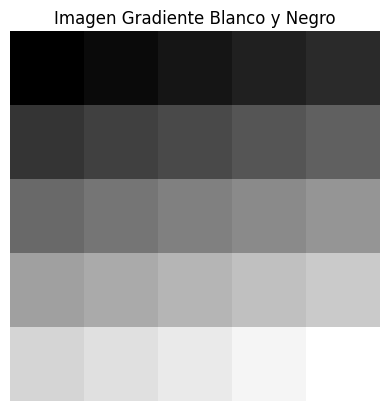

Flatten shape: (25,)
[0.         0.04166667 0.08333333 0.125      0.16666667 0.20833333
 0.25       0.29166667 0.33333333 0.375      0.41666667 0.45833333
 0.5        0.54166667 0.58333333 0.625      0.66666667 0.70833333
 0.75       0.79166667 0.83333333 0.875      0.91666667 0.95833333
 1.        ]


In [5]:
# Imagen en escala de grises: gradiente
img_gray = np.linspace(0, 1, 25).reshape(5, 5)

# Mostrar imagen
plt.imshow(img_gray, cmap='gray')
plt.title("Imagen Gradiente Blanco y Negro")
plt.axis('off')
plt.show()

# Flatten
flattened = img_gray.flatten()
print("Flatten shape:", flattened.shape)
print(flattened)

### **3.2 Imagen con letra "P" en píxeles**

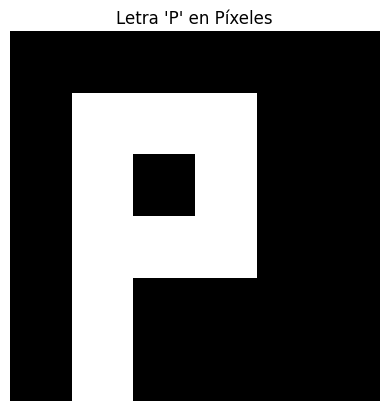

Flatten shape: (36,)
[0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [6]:
img_p = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0]
], dtype=np.float32)

plt.imshow(img_p, cmap='gray')
plt.title("Letra 'P' en Píxeles")
plt.axis('off')
plt.show()

flattened_p = img_p.flatten()
print("Flatten shape:", flattened_p.shape)
print(flattened_p)

### **3.3 Imagen RGB cargada por el usuario**

In [7]:
from PIL import Image

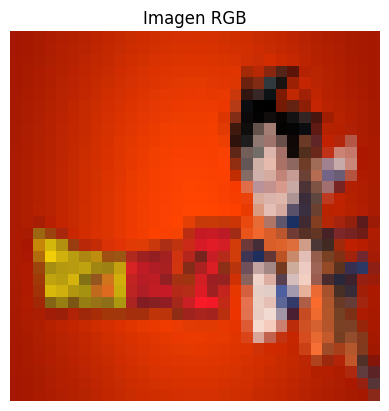

Flatten shape: (3072,)
[165  23   0 166  25   0 169  27   0 173  28   1 176  31   1 179  32   0
 184  34   1 189  36   0 193  38   0 197  41   1 200  44   0 206  44   0
 207  46   0 210  48   1 212  48   2 212  48   1 212  48]


In [9]:
# Leer imagen
image_path = "/content/dragon.jfif"
image = Image.open(image_path).resize((32, 32))
image_np = np.array(image)

plt.imshow(image_np)
plt.title("Imagen RGB")
plt.axis('off')
plt.show()

# Flatten RGB
flattened_rgb = image_np.flatten()
print("Flatten shape:", flattened_rgb.shape)
print(flattened_rgb[:50])  # Mostrar primeros valores

## **4. ¿Cuándo usar Flatten?**

- Antes de conectar la salida de una red convolucional a una capa densa.
- Cuando necesitás transicionar de operaciones espaciales (2D o 3D) a una representación vectorial.
- Ideal al final del bloque convolucional justo antes del clasificador (capa densa softmax, por ejemplo).


## **5. Tips**

- No confundas Flatten con `reshape()` a ojo: el orden de las dimensiones puede impactar el rendimiento.
- Si estás usando CNNs con imágenes de diferentes tamaños, asegurate de controlar bien el `shape` de salida antes del flatten para evitar errores dimensionales.